In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'D:\SIC_P1_G16\dataset\housing_data_CDMX.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  object 
 1   places                      18234 non-null  object 
 2   lat-lon                     18234 non-null  object 
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  object 
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


In [4]:
df.head()

,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069


# Duplicated and nulls handling

In [5]:
df.duplicated().sum()

np.int64(2953)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.isnull().sum()

property_type                 0
places                        0
lat-lon                       0
price                         0
currency                      0
price_aprox_local_currency    0
price_aprox_usd               0
surface_total_in_m2           0
surface_covered_in_m2         0
price_usd_per_m2              0
price_per_m2                  0
dtype: int64

# split lat-lon column to two column

In [8]:
df[['latitude', 'longitude']] = df['lat-lon'].str.split(',', expand=True)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.drop('lat-lon', axis=1, inplace=True)

Chack nulls for new columns

In [9]:
df.isnull().sum()

property_type                   0
places                          0
price                           0
currency                        0
price_aprox_local_currency      0
price_aprox_usd                 0
surface_total_in_m2             0
surface_covered_in_m2           0
price_usd_per_m2                0
price_per_m2                    0
latitude                      103
longitude                     103
dtype: int64

In [10]:
df = df.dropna(subset=['latitude', 'longitude'])

In [11]:
df.head()

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444


# outliers handling

In [12]:
num_cols = df.select_dtypes(include=['number']).columns

print("Numerical columns:", num_cols)

df[num_cols].describe().round()

Numerical columns: Index(['price', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'latitude', 'longitude'],
      dtype='object')


,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0,15178.0
mean,3756191.0,5497853.0,292307.0,4857.0,4830.0,1510.0,24335.0,19.0,-99.0
std,5885216.0,10305725.0,547929.0,534076.0,534074.0,2287.0,43688.0,1.0,0.0
min,7000.0,109031.0,5797.0,1.0,1.0,0.0,0.0,19.0,-103.0
25%,1030000.0,1090307.0,57969.0,70.0,70.0,660.0,11125.0,19.0,-99.0
50%,2000000.0,2308625.0,122744.0,100.0,100.0,1068.0,17792.0,19.0,-99.0
75%,4110000.0,4955944.0,263495.0,205.0,218.0,1900.0,32000.0,19.0,-99.0
max,233726700.0,336484065.0,17890000.0,65748000.0,65748000.0,175918.0,3338953.0,42.0,-90.0


In [13]:
df.shape

(15178, 12)

In [14]:
num_cols = [
    'price',
    'price_aprox_local_currency',
    'price_aprox_usd',
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'price_usd_per_m2',
    'price_per_m2'
]

mask = pd.Series(True, index=df.index)

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    mask &= df[col].between(lower,df[col].max())

    print(f"{col}: {outliers} outliers")

df = df[mask]

price: 1384 outliers
price_aprox_local_currency: 1936 outliers
price_aprox_usd: 1936 outliers
surface_total_in_m2: 1395 outliers
surface_covered_in_m2: 1290 outliers
price_usd_per_m2: 805 outliers
price_per_m2: 500 outliers


In [15]:
df.shape

(15178, 12)

In [16]:
df[num_cols] = df[num_cols].round()

In [17]:
df.describe()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,1.517800e+04,1.517800e+04,1.517800e+04,1.517800e+04,1.517800e+04,15178.000000,1.517800e+04,15178.000000,15178.000000
mean,3.756191e+06,5.497853e+06,2.923068e+05,4.857062e+03,4.829817e+03,1509.827250,2.433529e+04,19.440262,-99.206676
std,5.885216e+06,1.030572e+07,5.479291e+05,5.340756e+05,5.340743e+05,2287.032266,4.368838e+04,0.510603,0.398425
min,7.000000e+03,1.090310e+05,5.797000e+03,1.000000e+00,1.000000e+00,0.000000,0.000000e+00,19.185852,-102.552788
25%,1.030000e+06,1.090307e+06,5.796900e+04,7.000000e+01,7.000000e+01,660.000000,1.112500e+04,19.350214,-99.195413
50%,2.000000e+06,2.308625e+06,1.227440e+05,1.000000e+02,1.000000e+02,1067.500000,1.779150e+04,19.387579,-99.164666
75%,4.110000e+06,4.955944e+06,2.634950e+05,2.050000e+02,2.177500e+02,1900.000000,3.200000e+04,19.425110,-99.135621
max,2.337267e+08,3.364841e+08,1.789000e+07,6.574800e+07,6.574800e+07,175918.000000,3.338953e+06,41.577487,-90.488467


In [18]:
(df[num_cols] < 10).sum()

price                          0
price_aprox_local_currency     0
price_aprox_usd                0
surface_total_in_m2            6
surface_covered_in_m2         10
price_usd_per_m2              16
price_per_m2                   5
dtype: int64

In [19]:
for col in num_cols:
    df = df[(df[col] >= 10)]

In [20]:
df.describe().round()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,15152.0,15152.0,15152.0,15152.0,15152.0,15152.0,15152.0,15152.0,15152.0
mean,3759072.0,5499731.0,292407.0,214.0,196.0,1497.0,23918.0,19.0,-99.0
std,5888576.0,10304646.0,547872.0,1436.0,999.0,1967.0,34252.0,1.0,0.0
min,7000.0,109031.0,5797.0,10.0,10.0,10.0,20.0,19.0,-103.0
25%,1030000.0,1090307.0,57969.0,70.0,70.0,661.0,11138.0,19.0,-99.0
50%,2007000.0,2316738.0,123175.0,100.0,100.0,1069.0,17800.0,19.0,-99.0
75%,4125083.0,4955944.0,263495.0,204.0,216.0,1900.0,32000.0,19.0,-99.0
max,233726700.0,336484065.0,17890000.0,113100.0,113100.0,175918.0,3338953.0,42.0,-90.0


In [21]:
df

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450246.0,289776.0,54.0,54.0,5366.0,101852.0,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498322.0,79662.0,80.0,80.0,996.0,18900.0,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.0,48823.0,100.0,100.0,488.0,9267.0,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.0,337720.0,135.0,135.0,2502.0,47481.0,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376052.0,232664.0,87.0,87.0,2674.0,50759.0,19.432657,-99.177444
...,...,...,...,...,...,...,...,...,...,...,...,...
18229,apartment,Coyoacan,4154400.0,MXN,4116818.0,218881.0,157.0,157.0,1394.0,26461.0,19.336994,-99.162355
18230,house,AlvaroObregon,706448.0,MXN,700223.0,37229.0,105.0,105.0,355.0,6728.0,19.342911,-99.224472
18231,apartment,Cuauhtemoc,621880.0,MXN,616254.0,32765.0,130.0,130.0,252.0,4784.0,19.408758,-99.129474
18232,house,MiguelHidalgo,13000000.0,MXN,12885453.0,685087.0,316.0,350.0,2168.0,37143.0,19.401079,-99.248070


# **Exploratory Data Analysis (EDA)**

#### **Segmenting the dataset into two distinct categories: Standard and Luxury markets**

In [22]:
df_Luxury=df[(df['surface_total_in_m2'] > 1000) | (df['price_aprox_usd'] > 1000000)].copy()
print(df_Luxury.shape)
df_Luxury.head()

(1069, 12)


,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
15,apartment,MiguelHidalgo,1016611.0,USD,19120928.0,1016611.0,149.0,149.0,6823.0,6823.0,19.407269,-99.190754
25,apartment,MiguelHidalgo,1750000.0,USD,32914875.0,1750000.0,734.0,734.0,2384.0,2384.0,19.420166,-99.220367
28,apartment,MiguelHidalgo,1125000.0,USD,21159562.0,1125000.0,260.0,260.0,4327.0,4327.0,19.430456,-99.188912
47,apartment,MiguelHidalgo,20000000.0,MXN,19823775.0,1053980.0,190.0,190.0,5547.0,105263.0,19.430456,-99.188912
70,house,MiguelHidalgo,4000000.0,USD,75234000.0,4000000.0,713.0,451.0,5610.0,8869.0,19.420166,-99.220367


In [23]:

df=df[df["surface_total_in_m2"]<=1000]
df=df[df['price_aprox_usd'] <= 1000000]
df.shape


(14083, 12)

## **Standard markets**

 **1-Descriptive Statistics Overview**

In [24]:
df[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,14083.0,3153768.93,3272491.91,7000.0,992924.0,1990000.0,3967821.0,18970000.0
price_aprox_local_currency,14083.0,3438681.77,3659402.64,109031.0,1038658.5,2081003.0,4261101.0,18808500.0
price_aprox_usd,14083.0,182825.95,194561.11,5797.0,55223.0,110642.0,226552.0,1000000.0
surface_total_in_m2,14083.0,144.34,129.48,10.0,68.0,90.0,175.0,1000.0
surface_covered_in_m2,14083.0,147.11,131.96,10.0,68.0,90.0,180.0,1900.0
price_usd_per_m2,14083.0,1336.29,1077.48,15.0,651.0,1013.0,1756.0,25893.0
price_per_m2,14083.0,23590.23,18705.18,20.0,11718.5,18143.0,31874.0,491448.0


**Correlations**

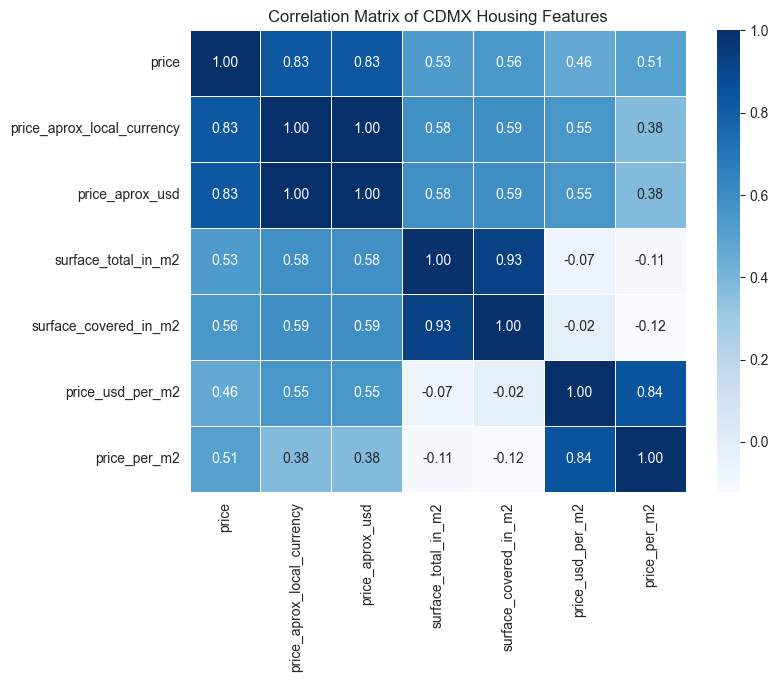

In [25]:
correlation_matrix =df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of CDMX Housing Features')
plt.show()

## **extract KPIs**

In [26]:
total_properties = len(df)
avg_price_usd = df['price_aprox_usd'].mean()
avg_price_m2_usd = df['price_usd_per_m2'].mean()

print(f"Total Properties: {total_properties:,.0f}")
print(f"Average Property Price: ${avg_price_usd:,.2f}")
print(f"Average Price per m²: ${avg_price_m2_usd:,.2f}")

Total Properties: 14,083
Average Property Price: $182,825.95
Average Price per m²: $1,336.29


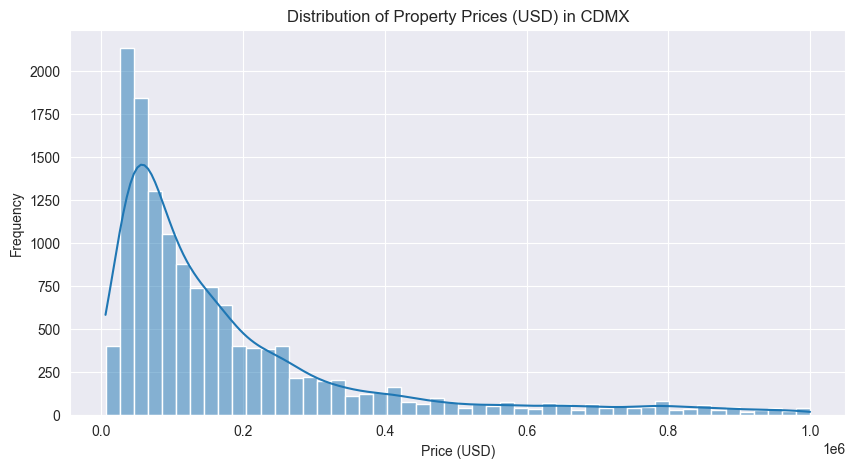

In [27]:
# Plot the distribution of property prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price_aprox_usd'], bins=50, kde=True)
plt.title('Distribution of Property Prices (USD) in CDMX')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

## **Property Type Insights**

In [28]:
# Aggregate data by property type
type_insights = df.groupby('property_type').agg(
    property_count=('property_type', 'count'),
    avg_price_usd=('price_aprox_usd', 'mean'),
    avg_price_per_m2=('price_usd_per_m2', 'mean')
).round(2).sort_values(by='avg_price_usd', ascending=False)
display(type_insights)



,property_count,avg_price_usd,avg_price_per_m2
property_type,,,
PH,10,431198.30,1859.40
house,3974,244506.15,1120.31
store,130,202738.90,1753.05
apartment,9969,157729.20,1416.44


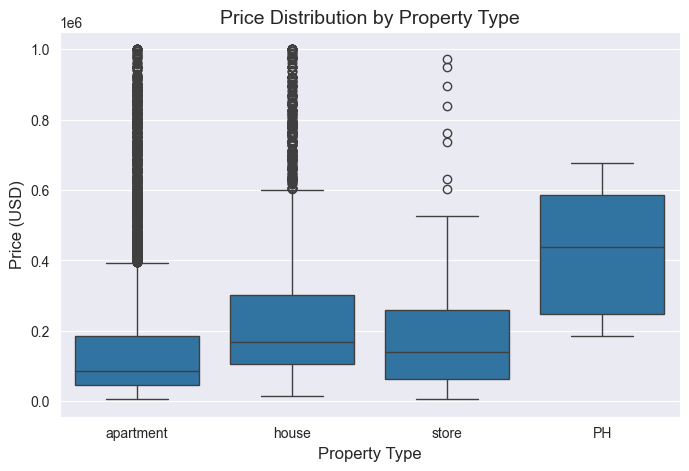

In [29]:
# Plot price distribution by property type to spot outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='property_type', y='price_aprox_usd')
plt.title('Price Distribution by Property Type', fontsize=14)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()

## ****Top Places Analysis****

In [30]:
# Extract the most expensive places by price
borough_prices = df.groupby('places')['price_aprox_usd'].mean().round(2).sort_values(ascending=True)
borough_prices

places
Tlahuac                57900.96
Iztapalapa             71232.03
VenustianoCarranza     72585.56
Iztacalco              73316.91
MilpaAlta              85635.50
Azcapotzalco           86407.65
GustavoAMadero        104738.10
Cuauhtemoc            140042.92
Xochimilco            158921.75
Coyoacan              168595.73
BenitoJuarez          170916.81
AlvaroObregon         210203.02
Tlalpan               224008.72
MagdalenaContreras    286713.39
MiguelHidalgo         342402.92
Cuajimalpa            437940.64
Name: price_aprox_usd, dtype: float64

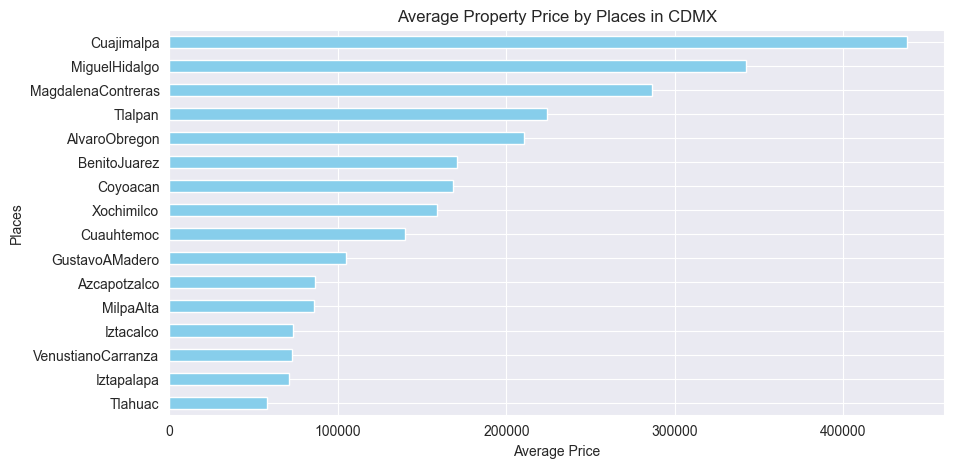

In [31]:
plt.figure(figsize=(10, 5))
borough_prices.plot(kind='barh', color='skyblue')
plt.title('Average Property Price by Places in CDMX')
plt.xlabel('Average Price')
plt.ylabel('Places')
plt.show()

In [32]:
# Extract the top 10 most expensive places by price per square meter
top_10_places = df.groupby('places')['price_usd_per_m2'].mean().sort_values(ascending=False).head(10)
top_10_places.round(2)

places
MiguelHidalgo         2023.72
Cuajimalpa            1955.47
BenitoJuarez          1597.87
AlvaroObregon         1395.24
Cuauhtemoc            1384.97
MagdalenaContreras    1296.40
Coyoacan              1232.68
Tlalpan               1140.37
Azcapotzalco           872.17
VenustianoCarranza     839.65
Name: price_usd_per_m2, dtype: float64

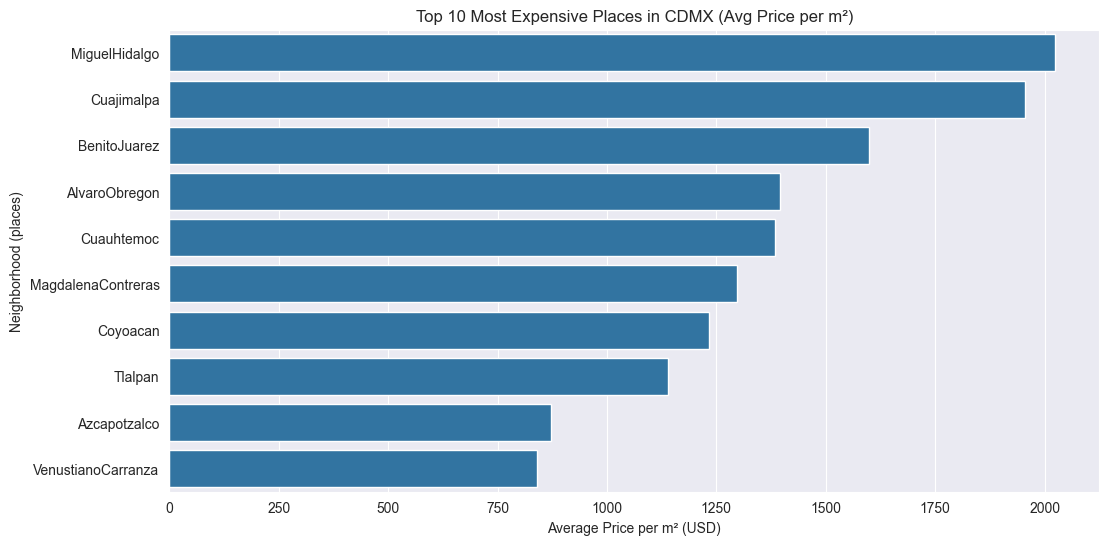

In [33]:
# Visualize the top 10 places using a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_places.values, y=top_10_places.index)
plt.title('Top 10 Most Expensive Places in CDMX (Avg Price per m²)')
plt.xlabel('Average Price per m² (USD)')
plt.ylabel('Neighborhood (places)')
plt.show()

**Surface Area vs. Price Correlation**

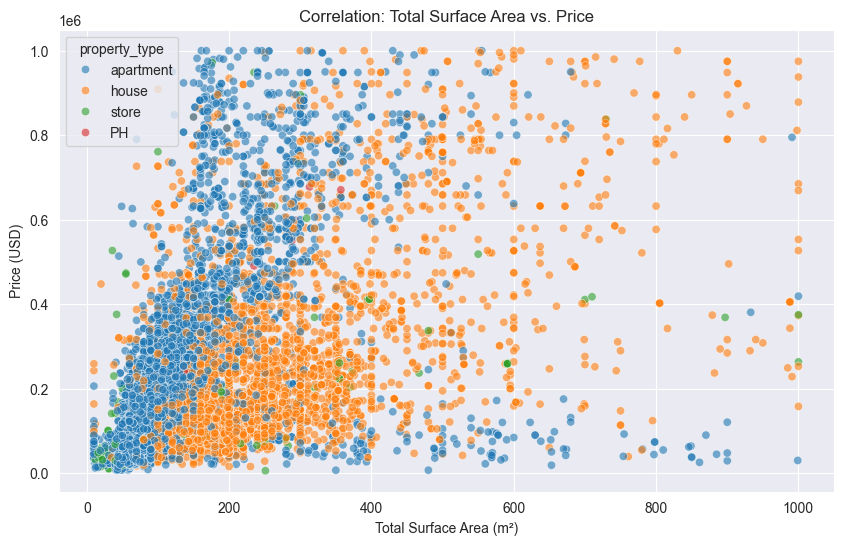

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='surface_total_in_m2', y='price_aprox_usd', hue='property_type', alpha=0.6)
plt.title('Correlation: Total Surface Area vs. Price', )
plt.xlabel('Total Surface Area (m²)')
plt.ylabel('Price (USD)')
plt.show()

**Create a new column classifying the property: Does it have an outdoor space or not?**

In [35]:
df["has_garden"]=df["surface_total_in_m2"]-df["surface_covered_in_m2"]
df["has_garden"]=df["has_garden"].apply(lambda x: "Yes" if x > 0 else "No")
df["has_garden"].head()

0    No
1    No
2    No
3    No
4    No
Name: has_garden, dtype: object

In [36]:
garden_prices = df.groupby('has_garden')['price_aprox_usd'].mean().round(2)
garden_prices

has_garden
No     176263.51
Yes    372899.28
Name: price_aprox_usd, dtype: float64

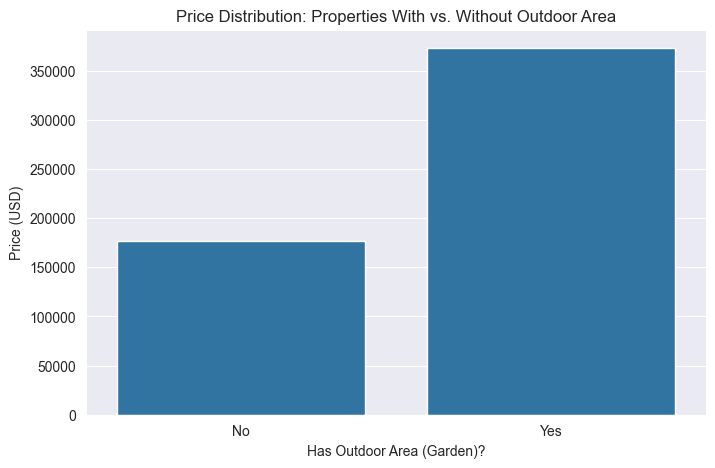

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(x=garden_prices.index, y=garden_prices.values)
plt.title('Price Distribution: Properties With vs. Without Outdoor Area')
plt.xlabel('Has Outdoor Area (Garden)?')
plt.ylabel('Price (USD)')
plt.show()

In [38]:
df.drop(columns=['price_aprox_local_currency','price',"price_per_m2","surface_covered_in_m2"], inplace=True)

In [39]:
df.to_csv(r'D:\SIC_P1_G16\dataset\housing_data_CDMX_cleaned.csv', index=True)

## **Luxury markets**
**check if data correct or not**

In [40]:
df_Luxury["property_type"].value_counts()

property_type
apartment    545
house        499
store         21
PH             4
Name: count, dtype: int64

In [41]:
df_Luxury["price_aprox_usd"].describe().round(2)

count        1069.00
mean      1736022.45
std       1230763.65
min         22128.00
25%       1150000.00
50%       1453325.00
75%       2000000.00
max      17890000.00
Name: price_aprox_usd, dtype: float64

In [42]:
df_Luxury['price_usd_per_m2'].describe().round(2)

count      1069.00
mean       3614.53
std        5893.73
min          10.00
25%        1694.00
50%        3011.00
75%        4994.00
max      175918.00
Name: price_usd_per_m2, dtype: float64

In [43]:
df_Luxury['places'].value_counts().head(5)

places
MiguelHidalgo    546
Cuajimalpa       170
AlvaroObregon    170
Tlalpan           55
Cuauhtemoc        40
Name: count, dtype: int64

In [44]:
df_Luxury = df_Luxury[~((df_Luxury['property_type'] == 'apartment') & (df_Luxury['surface_total_in_m2'] > 1000))]
df_Luxury = df_Luxury[(df_Luxury['price_usd_per_m2'] > 100) & (df_Luxury['price_usd_per_m2'] < 50000)]
print(df_Luxury.shape)
df_Luxury.head()

(983, 12)


,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
15,apartment,MiguelHidalgo,1016611.0,USD,19120928.0,1016611.0,149.0,149.0,6823.0,6823.0,19.407269,-99.190754
25,apartment,MiguelHidalgo,1750000.0,USD,32914875.0,1750000.0,734.0,734.0,2384.0,2384.0,19.420166,-99.220367
28,apartment,MiguelHidalgo,1125000.0,USD,21159562.0,1125000.0,260.0,260.0,4327.0,4327.0,19.430456,-99.188912
47,apartment,MiguelHidalgo,20000000.0,MXN,19823775.0,1053980.0,190.0,190.0,5547.0,105263.0,19.430456,-99.188912
70,house,MiguelHidalgo,4000000.0,USD,75234000.0,4000000.0,713.0,451.0,5610.0,8869.0,19.420166,-99.220367


**The number of luxury properties in each neighborhood**

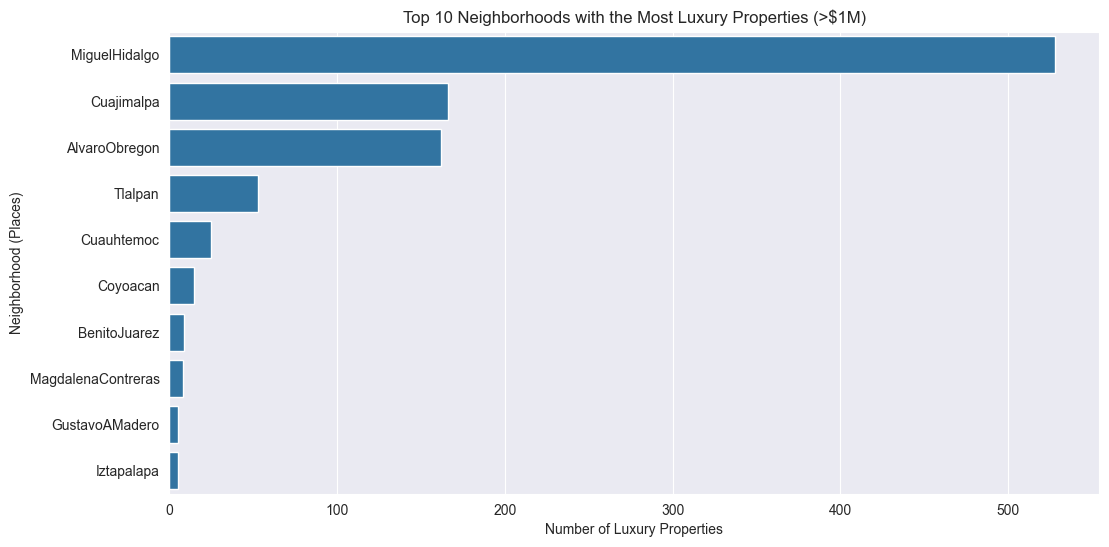

In [46]:
plt.figure(figsize=(12, 6))
luxury_neighborhoods = df_Luxury['places'].value_counts().head(10)

sns.barplot(x=luxury_neighborhoods.values, y=luxury_neighborhoods.index)
plt.title('Top 10 Neighborhoods with the Most Luxury Properties (>$1M)')
plt.xlabel('Number of Luxury Properties')
plt.ylabel('Neighborhood (Places)')
plt.show()

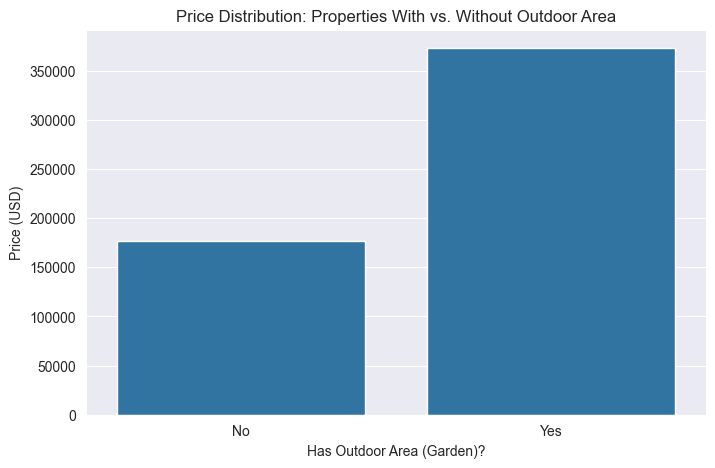

In [48]:
df_Luxury["has_garden"]=df_Luxury["surface_total_in_m2"]-df_Luxury["surface_covered_in_m2"]
df_Luxury["has_garden"]=df_Luxury["has_garden"].apply(lambda x: "Yes" if x > 0 else "No")
garden_prices = df.groupby('has_garden')['price_aprox_usd'].mean().round(2)
plt.figure(figsize=(8, 5))
sns.barplot(x=garden_prices.index, y=garden_prices.values)
plt.title('Price Distribution: Properties With vs. Without Outdoor Area')
plt.xlabel('Has Outdoor Area (Garden)?')
plt.ylabel('Price (USD)')
plt.show()

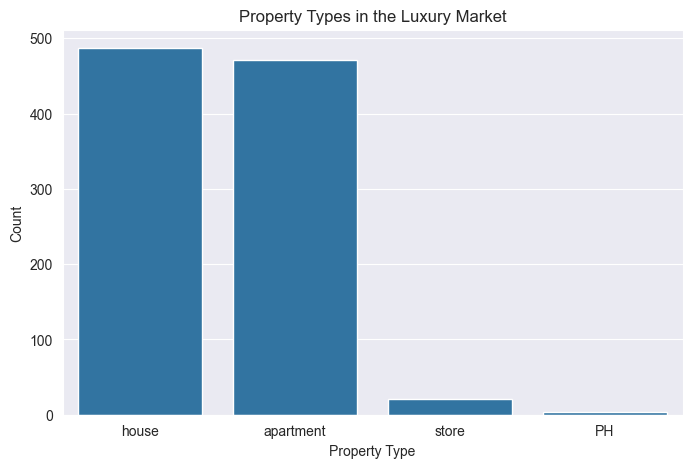

In [51]:

plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(data=df_Luxury, x='property_type', order=df_Luxury['property_type'].value_counts().index)

plt.title('Property Types in the Luxury Market')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.show()

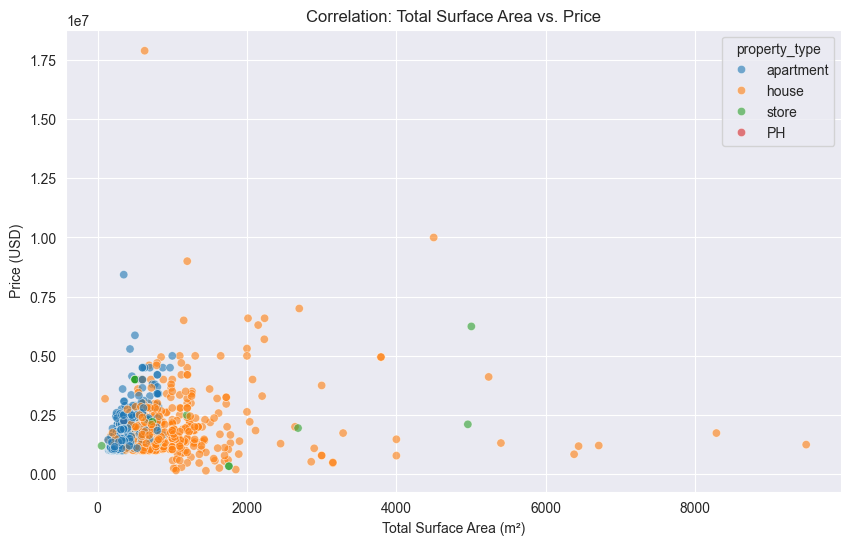

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_Luxury, x='surface_total_in_m2', y='price_aprox_usd', hue='property_type', alpha=0.6)
plt.title('Correlation: Total Surface Area vs. Price', )
plt.xlabel('Total Surface Area (m²)')
plt.ylabel('Price (USD)')
plt.show()

In [55]:
df_Luxury.drop(columns=['price_aprox_local_currency','price',"price_per_m2","surface_covered_in_m2"], inplace=True)

In [56]:
df_Luxury.to_csv(r'D:\SIC_P1_G16\dataset\housing_data_CDMX_cleaned_Luxury.csv', index=True)